In [3]:
import json
import os
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3r.behaviour as p3b

Load and preprocess tracking files

In [29]:
DATA_DIR = "/Users/nataliyastempkovska/PycharmProjects/Focus_Project_2D/OFT/test"
FPS = 30
N_CLUSTERS = 25

In [30]:
tc = p3b.TrackingCollection.from_yolo3r_folder(folder_path=DATA_DIR, fps=FPS)

In [31]:
tc.each.strip_column_names()
tc.each.filter_likelihood(threshold=0.7)
tc.each.interpolate(limit=5)
tc.each.smooth_all(window=3, method="mean")
tc.each.rescale_by_known_distance(
    point1="tl",
    point2="br",
    distance_in_metres=0.64,
)

BatchResult: 5 items processed (in-place)

After preprocessing the tracking files, we create a FeaturesCollection object and compute the necessary features for clustering.

In [49]:
fc = p3b.FeaturesCollection.from_tracking_collection(tc)

In [50]:
ordered_oft_corners = ["tl", "tr", "br", "bl"]

_ = fc.each.define_static_boundary(
    ordered_oft_corners,
    name="oft",
)

for pt in ["nose", "neck", "earr", "earl", "bodycentre", "hipl", "hipr", "tailbase"]:
    fc.each.speed(pt, dims=["x", "y", "z"]).store()

for basepoint, pointdirection1, pointdirection2 in [
    ("tailbase", "hipr", "hipl"),
    ("bodycentre", "tailbase", "neck"),
    ("neck", "bodycentre", "headcentre"),
    ("headcentre", "earr", "earl"),
]:
    fc.each.azimuth_deviation(basepoint, pointdirection1, pointdirection2).store()

for p1, p2 in [
    ("nose", "headcentre"),
    ("neck", "headcentre"),
    ("neck", "bodycentre"),
    ("bcr", "bodycentre"),
    ("bcl", "bodycentre"),
    ("tailbase", "bodycentre"),
    ("tailbase", "hipr"),
    ("tailbase", "hipl"),
    ("bcr", "hipr"),
    ("bcl", "hipl"),
    ("bcl", "earl"),
    ("bcr", "earr"),
    ("nose", "earr"),
    ("nose", "earl"),
]:
    fc.each.distance_between(p1, p2, dims=["x", "y", "z"]).store()

DYNAMIC_BODY_BOUNDARIES = [
    ("mouse_rear", ["tailbase", "hipr", "hipl"]),
    ("mouse_mid", ["hipr", "hipl", "bcl", "bcr"]),
    ("mouse_front", ["bcr", "earr", "earl", "bcl"]),
    ("mouse_face", ["earr", "nose", "earl"]),
]
for boundary_name, boundary_points in DYNAMIC_BODY_BOUNDARIES:
    fc.each.define_dynamic_boundary(boundary_points, name=boundary_name)
    fc.each.area_of_boundary(boundary_name).store()
for pt in ["nose", "neck", "bodycentre", "tailbase"]:
    fc.each.distance_to_boundary(pt, "oft").store()


In [51]:
fc[0].data

,speed_of_nose_in_xyz,speed_of_neck_in_xyz,speed_of_earr_in_xyz,speed_of_earl_in_xyz,speed_of_bodycentre_in_xyz,speed_of_hipl_in_xyz,speed_of_hipr_in_xyz,speed_of_tailbase_in_xyz,azimuth_deviation_tailbase_to_hipr_and_hipl,azimuth_deviation_bodycentre_to_tailbase_and_neck,...,distance_between_nose_and_earr_in_xyz,distance_between_nose_and_earl_in_xyz,area_of_boundary_mouse_rear_dynamic,area_of_boundary_mouse_mid_dynamic,area_of_boundary_mouse_front_dynamic,area_of_boundary_mouse_face_dynamic,distance_to_boundary_static_nose_in_oft,distance_to_boundary_static_neck_in_oft,distance_to_boundary_static_bodycentre_in_oft,distance_to_boundary_static_tailbase_in_oft
frame,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.439435,3.061986,...,0.586513,0.619163,0.000286,0.000653,0.000675,0.000213,0.050384,0.078547,0.106909,0.147176
2,0.881186,0.411699,1.135736,0.784740,0.750615,0.856024,1.022902,1.686460,1.451754,3.058682,...,0.519340,0.563693,0.000282,0.000660,0.000682,0.000207,0.050486,0.077932,0.106495,0.146754
3,0.563596,0.662502,0.580694,2.530729,2.001268,0.485774,0.397228,0.849521,1.458670,3.053259,...,0.518751,0.498165,0.000278,0.000664,0.000689,0.000205,0.050078,0.077149,0.106097,0.146253
4,0.630246,1.497292,0.769884,1.097981,2.903401,1.129487,0.751131,1.276572,1.464555,3.050245,...,0.565359,0.555685,0.000274,0.000666,0.000692,0.000206,0.049428,0.076498,0.105653,0.145727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18090,1.216538,0.830962,0.367143,1.415064,1.473551,0.197315,0.250397,0.544059,1.508645,-3.018951,...,0.027981,0.410590,0.000331,0.000417,0.000472,0.000265,0.168012,0.184126,0.179952,0.154723
18091,1.089273,0.309429,0.515870,0.864864,1.703575,1.070144,0.014375,0.403980,1.511356,-3.022226,...,0.063980,0.475592,0.000329,0.000416,0.000469,0.000262,0.168408,0.184251,0.179798,0.154711
18092,0.429326,0.448153,0.224260,0.016761,0.060234,0.317778,0.703853,0.085632,1.514648,-3.025150,...,0.045188,0.461741,0.000325,0.000417,0.000466,0.000259,0.168870,0.184560,0.179770,0.154673


Now that we have all the features computed, we can start with k-means clustering.

In [52]:
cluster_features = fc[0].data.columns
offset = list(np.arange(-15, 16, 1))
embedding_dict = {f: offset for f in cluster_features}

In [53]:
cluster_labels, centroids, _ = fc.cluster_embedding_stream(
    embedding_dict=embedding_dict,
    n_clusters=N_CLUSTERS,
    missing_policy="impute_weight"
)
cluster_labels.store(f"kmeans_{N_CLUSTERS}", overwrite=True)

'kmeans_25'

In [54]:
fc[0].data

,speed_of_nose_in_xyz,speed_of_neck_in_xyz,speed_of_earr_in_xyz,speed_of_earl_in_xyz,speed_of_bodycentre_in_xyz,speed_of_hipl_in_xyz,speed_of_hipr_in_xyz,speed_of_tailbase_in_xyz,azimuth_deviation_tailbase_to_hipr_and_hipl,azimuth_deviation_bodycentre_to_tailbase_and_neck,...,distance_between_nose_and_earl_in_xyz,area_of_boundary_mouse_rear_dynamic,area_of_boundary_mouse_mid_dynamic,area_of_boundary_mouse_front_dynamic,area_of_boundary_mouse_face_dynamic,distance_to_boundary_static_nose_in_oft,distance_to_boundary_static_neck_in_oft,distance_to_boundary_static_bodycentre_in_oft,distance_to_boundary_static_tailbase_in_oft,kmeans_25
frame,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.439435,3.061986,...,0.619163,0.000286,0.000653,0.000675,0.000213,0.050384,0.078547,0.106909,0.147176,5
2,0.881186,0.411699,1.135736,0.784740,0.750615,0.856024,1.022902,1.686460,1.451754,3.058682,...,0.563693,0.000282,0.000660,0.000682,0.000207,0.050486,0.077932,0.106495,0.146754,5
3,0.563596,0.662502,0.580694,2.530729,2.001268,0.485774,0.397228,0.849521,1.458670,3.053259,...,0.498165,0.000278,0.000664,0.000689,0.000205,0.050078,0.077149,0.106097,0.146253,5
4,0.630246,1.497292,0.769884,1.097981,2.903401,1.129487,0.751131,1.276572,1.464555,3.050245,...,0.555685,0.000274,0.000666,0.000692,0.000206,0.049428,0.076498,0.105653,0.145727,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18090,1.216538,0.830962,0.367143,1.415064,1.473551,0.197315,0.250397,0.544059,1.508645,-3.018951,...,0.410590,0.000331,0.000417,0.000472,0.000265,0.168012,0.184126,0.179952,0.154723,15
18091,1.089273,0.309429,0.515870,0.864864,1.703575,1.070144,0.014375,0.403980,1.511356,-3.022226,...,0.475592,0.000329,0.000416,0.000469,0.000262,0.168408,0.184251,0.179798,0.154711,14
18092,0.429326,0.448153,0.224260,0.016761,0.060234,0.317778,0.703853,0.085632,1.514648,-3.025150,...,0.461741,0.000325,0.000417,0.000466,0.000259,0.168870,0.184560,0.179770,0.154673,14


After clustering, we can start visualizing our results.

In [55]:
sc = p3b.SummaryCollection.from_features_collection(fc)

In [56]:
sc.each.time_in_state(f"kmeans_{N_CLUSTERS}").store("time_in_cluster")

'time_in_cluster'

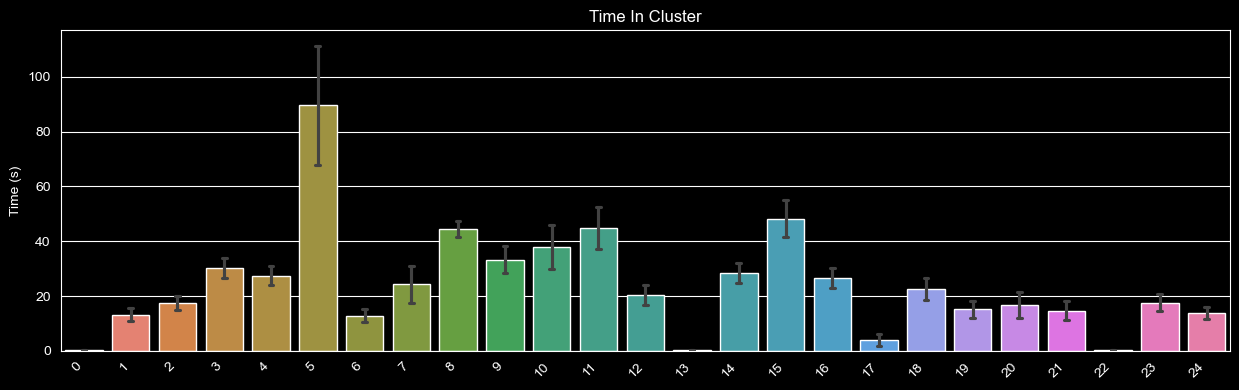

(<Figure size 1250x400 with 1 Axes>,
 <Axes: title={'center': 'Time In Cluster'}, ylabel='Time (s)'>,
     _handle component   Time (s)
 0         6         5  66.233333
 1         6        11  56.533333
 2         6         8  45.800000
 3         6        10  40.000000
 4         6         9  38.200000
 ..      ...       ...        ...
 117       8         6   9.466667
 118       8        17   4.233333
 119       8        22   0.333333
 120       8         0   0.066667
 121       8        13   0.033333
 
 [122 rows x 3 columns])

In [57]:
sc.snsbar(
    "time_in_cluster",
    show=True,
)